In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])



import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

In [2]:
# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

In [4]:
no_plates_20 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/no_plates_20cm.csv")
plates_20 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/plates_20cm.csv")
no_plates_30 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/no_plates_30cm.csv")
plates_30 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/plates_30cm.csv")

In [5]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # positions of probes in meters from wave maker
x_prof = x_probe_pos - x_probe_pos[0]  # positions of probes relative to the first probe

In [43]:
def plot_amplitudes_along_tank(df_no, df_with, f, volt_level, D):
    # Filter by frequency and voltage
    df_subset_no = df_no[(df_no["frequency"] == f) & (df_no["volt_level"] == volt_level)]
    df_subset_with = df_with[(df_with["frequency"] == f) & (df_with["volt_level"] == volt_level)]

    volt = df_subset_no["volt"].iloc[0]  # Get the actual voltage value for the title

    # Extract the row for each run 
    r1_no = df_subset_no[df_subset_no["run"] == "R1"].iloc[0]
    r2_no = df_subset_no[df_subset_no["run"] == "R2"].iloc[0]
    r3_no = df_subset_no[df_subset_no["run"] == "R3"].iloc[0]

    r1_with = df_subset_with[df_subset_with["run"] == "R1"].iloc[0]
    r2_with = df_subset_with[df_subset_with["run"] == "R2"].iloc[0]
    r3_with = df_subset_with[df_subset_with["run"] == "R3"].iloc[0]


    # Build 1D arrays of amplitudes in probe order P0–P3
    r1_amps_no = np.array([r1_no["amp_P0"], r1_no["amp_P1"], r1_no["amp_P2"], r1_no["amp_P3"]])
    r2_amps_no = np.array([r2_no["amp_P0"], r2_no["amp_P1"], r2_no["amp_P2"], r2_no["amp_P3"]])
    r3_amps_no = np.array([r3_no["amp_P0"], r3_no["amp_P1"], r3_no["amp_P2"], r3_no["amp_P3"]])

    r1_amps_with = np.array([r1_with["amp_P0"], r1_with["amp_P1"], r1_with["amp_P2"], r1_with["amp_P3"]])
    r2_amps_with = np.array([r2_with["amp_P0"], r2_with["amp_P1"], r2_with["amp_P2"], r2_with["amp_P3"]])
    r3_amps_with = np.array([r3_with["amp_P0"], r3_with["amp_P1"], r3_with["amp_P2"], r3_with["amp_P3"]])

    # Exponential decay profile (mean across runs)
    mean_p0_no = np.mean([r1_no["amp_P0"], r2_no["amp_P0"], r3_no["amp_P0"]])
    mean_p0_with = np.mean([r1_with["amp_P0"], r2_with["amp_P0"], r3_with["amp_P0"]])

    mean_alpha_no = np.mean([r1_no["alpha"], r2_no["alpha"], r3_no["alpha"]]) 
    mean_alpha_with = np.mean([r1_with["alpha"], r2_with["alpha"], r3_with["alpha"]])

    mean_exp_prof_no = mean_p0_no * np.exp(-x_prof * mean_alpha_no)
    mean_exp_prof_with = mean_p0_with * np.exp(-x_prof * mean_alpha_with)

    # exponential decay profile for each run
    exp_prof_r1_no = r1_no["amp_P0"] * np.exp(-x_prof * r1_no["alpha"])
    exp_prof_r2_no = r2_no["amp_P0"] * np.exp(-x_prof * r2_no["alpha"])
    exp_prof_r3_no = r3_no["amp_P0"] * np.exp(-x_prof * r3_no["alpha"])

    exp_prof_r1_with = r1_with["amp_P0"] * np.exp(-x_prof * r1_with["alpha"])
    exp_prof_r2_with = r2_with["amp_P0"] * np.exp(-x_prof * r2_with["alpha"])
    exp_prof_r3_with = r3_with["amp_P0"] * np.exp(-x_prof * r3_with["alpha"])

    # Corresponding standard errors
    r1_se_no = np.array([r1_no["se_P0"], r1_no["se_P1"], r1_no["se_P2"], r1_no["se_P3"]])
    r2_se_no = np.array([r2_no["se_P0"], r2_no["se_P1"], r2_no["se_P2"], r2_no["se_P3"]])
    r3_se_no = np.array([r3_no["se_P0"], r3_no["se_P1"], r3_no["se_P2"], r3_no["se_P3"]])

    r1_se_with = np.array([r1_with["se_P0"], r1_with["se_P1"], r1_with["se_P2"], r1_with["se_P3"]])
    r2_se_with = np.array([r2_with["se_P0"], r2_with["se_P1"], r2_with["se_P2"], r2_with["se_P3"]])
    r3_se_with = np.array([r3_with["se_P0"], r3_with["se_P1"], r3_with["se_P2"], r3_with["se_P3"]])

    # Plot the profile of amplitudes along the tank for both conditions
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    err_kwargs = dict(
        ecolor="grey",     
        elinewidth=1.0,   
        capsize=4,       
        capthick=1.0,       
    )

    ax[0].errorbar(x_probe_pos, r1_amps_no, color= 'C0', yerr=r1_se_no, fmt='o', **err_kwargs)
    ax[0].errorbar(x_probe_pos, r2_amps_no, color= 'C0', yerr=r2_se_no, fmt='o', **err_kwargs)
    ax[0].errorbar(x_probe_pos, r3_amps_no, color= 'C0', yerr=r3_se_no, fmt='o', **err_kwargs)

    ax[0].plot(x_probe_pos, mean_exp_prof_no, 'k--', label=rf'$\alpha={-mean_alpha_no:.4f} m^{{-1}}$')
    ax[0].plot(x_probe_pos, exp_prof_r1_no, 'k:', alpha=0.3)
    ax[0].plot(x_probe_pos, exp_prof_r2_no, 'k:', alpha=0.3)
    ax[0].plot(x_probe_pos, exp_prof_r3_no, 'k:', alpha=0.3)

    ax[0].set_xlabel('Distance from wave maker [m]')
    ax[0].set_ylabel('Amplitude [m]')
    ax[0].set_title(f'Without plates')
    ax[0].legend(loc='upper right')

    ax[1].errorbar(x_probe_pos, r1_amps_with, color= 'C1', yerr=r1_se_with, fmt='o', **err_kwargs)
    ax[1].errorbar(x_probe_pos, r2_amps_with, color= 'C1', yerr=r2_se_with, fmt='o', **err_kwargs)
    ax[1].errorbar(x_probe_pos, r3_amps_with, color= 'C1', yerr=r3_se_with, fmt='o', **err_kwargs)

    ax[1].plot(x_probe_pos, mean_exp_prof_with, 'k--', label=rf'$\alpha={-mean_alpha_with:.4f} m^{{-1}}$')
    ax[1].plot(x_probe_pos, exp_prof_r1_with, 'k:', alpha=0.3)
    ax[1].plot(x_probe_pos, exp_prof_r2_with, 'k:', alpha=0.3)
    ax[1].plot(x_probe_pos, exp_prof_r3_with, 'k:', alpha=0.3)

    ax[1].set_xlabel('Distance from wave maker [m]')
    ax[1].set_ylabel('Amplitude [m]')
    ax[1].set_title(f'With plates')
    ax[1].legend(loc='upper right')
    fig.suptitle(f'f={f} Hz, A={volt} V, D = {D} m')
    plt.tight_layout()
    fr = f"{f:.2f}".replace(".", "")
    am = f"{volt:.2f}".replace(".", "")
    de = f"{D:.2f}".replace(".", "")
    plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Figurer/amp_prof/prof_f{fr}_a{am}_d{de}.png", dpi=200)
    plt.close(fig)

In [44]:
f_20 = no_plates_20["frequency"].unique()
f_30 = no_plates_30["frequency"].unique()

D_20 = 0.2
D_30 = 0.3

In [50]:
for f in f_20:
    plot_amplitudes_along_tank(no_plates_20, plates_20, f, volt_level="low", D=D_20)
    plot_amplitudes_along_tank(no_plates_20, plates_20, f, volt_level="medium", D=D_20)
    plot_amplitudes_along_tank(no_plates_20, plates_20, f, volt_level="high", D=D_20)

for f in [1.6, 1.7, 1.8]:
    plot_amplitudes_along_tank(no_plates_20, plates_20, f, volt_level="medium-high", D=D_20)

In [52]:
for f in f_30:
    plot_amplitudes_along_tank(no_plates_30, plates_30, f, volt_level="low", D=D_30)
    plot_amplitudes_along_tank(no_plates_30, plates_30, f, volt_level="medium", D=D_30)
    plot_amplitudes_along_tank(no_plates_30, plates_30, f, volt_level="high", D=D_30)

for f in f_30[-3:-1]:
    plot_amplitudes_along_tank(no_plates_30, plates_30, f, volt_level="medium-high", D=D_30)

## Change in amplitude from first to last probe

In [ ]:
def find_change_in_amp(df):
    for row in df.itertuples():
        delta_amp = row.amp_P3 - row.amp_P0
        # Add to row
        df.loc[row.Index, 'delta_amp'] = delta_amp

    return df

In [59]:
no_plates_20 = find_change_in_amp(no_plates_20)
plates_20 = find_change_in_amp(plates_20)
no_plates_30 = find_change_in_amp(no_plates_30)
plates_30 = find_change_in_amp(plates_30)

NameError: name 'f20' is not defined

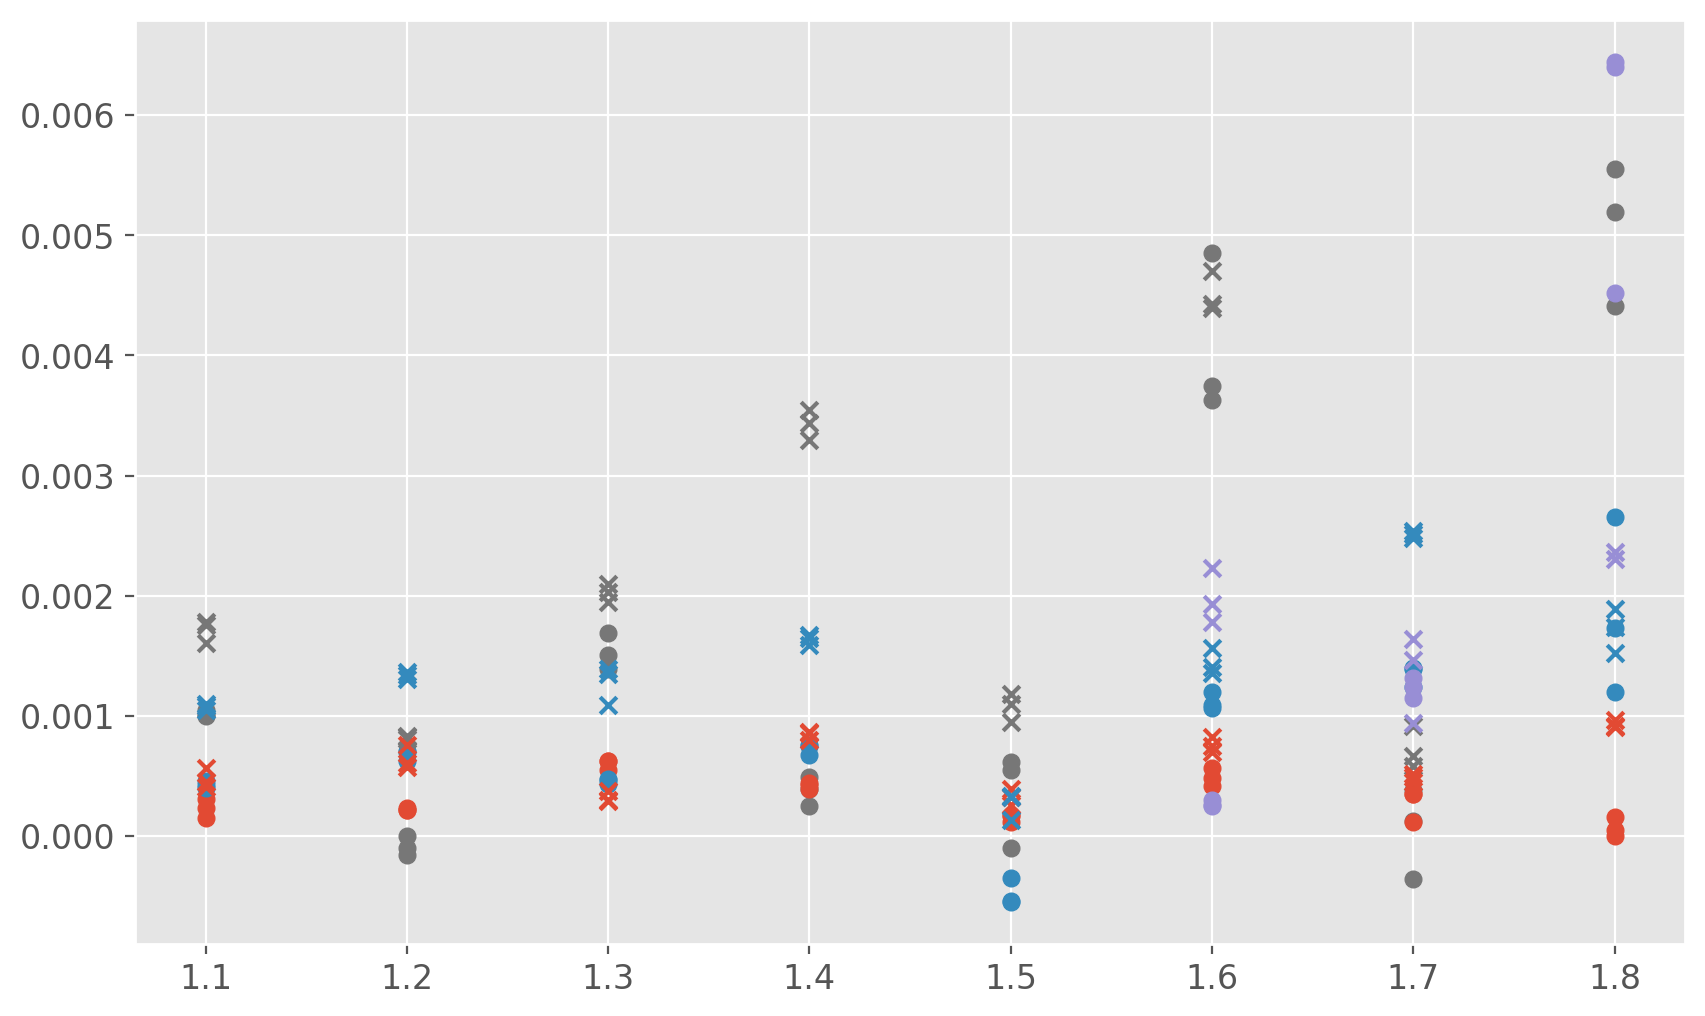

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))

level_colors = {
    "low":  "C0",
    "medium":  "C1",
    "medium-high": "C2",
    "high": "C3",
}

for level, sub in no_plates_20.groupby("volt_level"):
    ax.scatter(sub["frequency"], sub["delta_amp"],
               marker='o',
               label=f'{level} (No plates)',
               color=level_colors.get(level, "gray"))

for level, sub in plates_20.groupby("volt_level"):
    ax.scatter(sub["frequency"], sub["delta_amp"],
               label=f'{level} (Plates)',
               marker='x',
               color=level_colors.get(level, "gray"))


y1 = 0.001
y2 = -0.001

xmin = f20[0] - 0.05
xmax = f20[-1] + 0.05

plt.hlines(y1, xmin=xmin, xmax=xmax, colors='grey', linestyles='dashed')
plt.hlines(y2, xmin=xmin, xmax=xmax, colors='grey', linestyles='dashed')

x_fill = np.linspace(xmin, xmax, 50)
plt.fill_between(x_fill, y1, y2,
                 color='grey', alpha=0.2, edgecolor='none', zorder=0)

plt.legend(title='Voltage level', loc='lower left', ncol=2)
plt.minorticks_on()
plt.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray')

plt.xlabel('Frequency (Hz)')
plt.ylabel(r'Change in amplitude $\Delta A$ (m)')
plt.title(f'Change in amplitude from first to last probe (D= {D} m )')

## Damping coefficient as function of frequency